In [1]:
import numpy as np
import matplotlib.pyplot as plt

#functions to plot
def plot_graph(title, data, labels, colors, linestyles, x_label, y_label):
    print("-------------\n{}:".format(title))

    for d, l, c, ls in zip(data, labels, colors, linestyles):
        plt.plot(d, color=c, linestyle=ls, label=l)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.legend() # plt.legend()
    plt.show()

# Define moving average function


def moving_average(data, window_size):
    cumsum_vec = np.cumsum(np.insert(data, 0, 0))
    ma_vec = (cumsum_vec[window_size:] -
              cumsum_vec[:-window_size]) / window_size
    return ma_vec 


data_sac = np.load('O-RAN SAC, U=10, PRB=150, BS=4, E=20, T=5000, VELOCITY=10, D_max=10, R_min=10.npz')
data_heuristic = np.load('O-RAN Heuristic, U=10, PRB=80, BS=4, E=20, T=5000, VELOCITY=10, D_max=10, R_min=10.npz')
data_ddpg = np.load('O-RAN DDPG, U=10, PRB=150, BS=4, E=2, T=5000, VELOCITY=10, D_max=10, R_min=10.npz')


data_sac_v0 = np.load('O-RAN SAC, U=10, PRB=150, BS=4, E=20, T=5000, VELOCITY=0, D_max=10, R_min=10.npz')
data_heuristic_v0 = np.load('O-RAN Heuristic, U=10, PRB=80, BS=4, E=1, T=5000, VELOCITY=0, D_max=10, R_min=10.npz')
data_ddpg_v0 = np.load('O-RAN DDPG, U=10, PRB=150, BS=4, E=2, T=5000, VELOCITY=0, D_max=10, R_min=10.npz')
#############
reward_sac = data_sac['mat_reward']
reward_sac =reward_sac[:,:4200]


reward_heuristic = data_heuristic['mat_reward']
reward_heuristic =reward_heuristic[:,:4200]


reward_ddpg = data_ddpg['mat_reward']
reward_ddpg =reward_ddpg[:,:4200]

################

reward_sac_v0 = data_sac_v0['mat_reward']
reward_sac_v0 =reward_sac_v0[:,:4200]


reward_heuristic_v0 = data_heuristic_v0['mat_reward']
reward_heuristic_v0 =reward_heuristic_v0[:,:4200]


reward_ddpg_v0 = data_ddpg_v0['mat_reward']
reward_ddpg_v0 =reward_ddpg_v0[:,:4200]

#######################################

# Access the arrays stored in the .npz file


##
# Plot the results
WINDOW_SIZE =200
# WINDOW_SIZE_Heuristic =120



-------------
Reward:


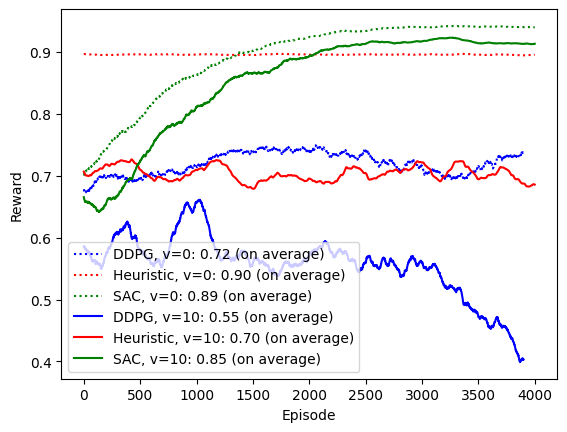

In [3]:
# WINDOW_SIZE = 20# reward_sac*=0.985
WINDOW_SIZE =200
data = [moving_average(np.average(reward_ddpg_v0, axis=0), 300), moving_average(np.average(reward_heuristic_v0, axis=0), WINDOW_SIZE), moving_average(np.average(reward_sac_v0, axis=0), WINDOW_SIZE), moving_average(np.average(reward_ddpg, axis=0), 300), moving_average(np.average(reward_heuristic, axis=0), WINDOW_SIZE), moving_average(np.average(reward_sac, axis=0), WINDOW_SIZE)]
names = ['DDPG, v=0', 'Heuristic, v=0', 'SAC, v=0', 'DDPG, v=10', 'Heuristic, v=10', 'SAC, v=10']
# averages = [np.average(np.average(reward_ddpg[:,2000:3998], axis=0)), np.average(np.average(reward_heuristic[:,2000:3998], axis=0)), np.average(np.average(reward_sac[:,2000:3998], axis=0))]
averages = [np.average(np.average(reward_ddpg_v0, axis=0)), np.average(np.average(reward_heuristic_v0, axis=0)), np.average(np.average(reward_sac_v0, axis=0)), np.average(np.average(reward_ddpg, axis=0)), np.average(np.average(reward_heuristic, axis=0)), np.average(np.average(reward_sac, axis=0))]
labels = ['{}: {:.2f} (on average)'.format(n, a) for n, a in zip(names, averages)]

colors = ['b', 'r', 'g', 'b', 'r', 'g']  # choose colors for each curve
linestyles = [':',':', ':','-', '-', '-']  # choose line styles for each curve

plot_graph('Reward', data, labels, colors, linestyles, "Episode", "Reward") 